> 🎯 **Projet : SmartFarm – Prédire la production d’œufs et détecter les lots à risque**

---

## 1. Idée générale du projet

Tu as (ou tu auras) plusieurs lots de poules pondeuses.
Pour chaque lot, chaque semaine, tu enregistres :

* ce que tu leur donnes (aliment),
* leurs conditions (température, mortalité, etc.),
* et le résultat (nombre d’œufs).

Avec ça tu vas :

1. **Régression 1** : prédire le nombre d’œufs/hen/jour pour un lot donné.
2. **Régression 2 (option)** : prédire la consommation d’aliment par poule.
3. **Classification binaire** : prédire si un lot sera **sous-performant** (à surveiller).
4. **Classification multi-classes** : classer un lot en **faible / moyen / très productif**.
5. Utiliser :

   * **régression linéaire** (simple + multiple),
   * **polynomial features**,
   * **gradient descent + feature scaling**,
   * **normal equation**,
   * **logistic regression**,
   * **regularization** (pour éviter l’overfitting).

Tu peux le faire :

* d’abord **en “from scratch”** avec NumPy comme dans le cours,
* puis **avec scikit-learn** pour un rendu plus “pro” pour ton CV.

---

## 2. Design du dataset (sur ta ferme)

👉 **Une ligne = un lot de poules sur une semaine**

### 2.1. Features proposées

| Colonne                | Type  | Description                                                           |
| ---------------------- | ----- | --------------------------------------------------------------------- |
| `week_id`              | int   | Identifiant de la semaine (1, 2, 3, …)                                |
| `flock_id`             | int   | Identifiant du lot                                                    |
| `age_weeks`            | float | Âge moyen des poules (en semaines)                                    |
| `num_hens`             | int   | Nombre de poules dans le lot                                          |
| `feed_g_per_hen_day`   | float | Quantité moyenne de nourriture par poule (g/jour)                     |
| `feed_type`            | cat   | Type d’aliment (ex: 0 = maïs seul, 1 = maïs+soja, 2 = maïs+son+soja…) |
| `avg_temp`             | float | Température moyenne (°C) dans le poulailler cette semaine             |
| `mortality_rate`       | float | % de mortalité cette semaine                                          |
| `avg_weight_kg`        | float | Poids moyen d’une poule dans le lot                                   |
| `lights_hours_per_day` | float | Nombre d’heures de lumière/jour                                       |
| `disease_outbreak`     | 0/1   | 1 si suspicion maladie cette semaine, sinon 0                         |


In [982]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from data.genrate_data import generate_poultry_data

In [983]:


data = generate_poultry_data()
data_size = float(data.shape[0])
seventy_pct = int(data_size * 0.7)
training_sets = data.head(seventy_pct)
testing_sets = data.head(int(data_size - seventy_pct))

X_train = training_sets['age_weeks'].values.astype(float)
Y_train = training_sets['eggs_per_hen_day'].values.astype(float)

x_test = testing_sets['age_weeks'].values.astype(float)
y_test = testing_sets['eggs_per_hen_day'].values.astype(float)

f_w_b = W*X+b

In [984]:
def model(x, w, b):
    return np.dot(w, x) + b

In [985]:
def cost_function(x, w, b, y):
    """
    j_w_b = (1/2m)*sum(f_w_b-y)^2
    :return:
    """
    m = x.shape[0]
    square_error = 0
    for i in range(m):
        f_w_b = w * x[i] + b
        square_error += (f_w_b - y[i]) ** 2
    j_w_b = square_error / (2 * m)
    return j_w_b


In [986]:
# def cost_function_vector(x, w, b, y):
#     m = x.shape[0]
#     cost = np.sum((model(w,b)-y)**2)
#     cost = cost/(2*m)
#     return cost
#     return cost

In [987]:
# cost_function_vector(x_train, 0.9, 0.5, y_train)

In [988]:
def compute_gradient(x, y, w, b):
    m = x.shape[0]
    dj_w = 0
    dj_b = 0
    for i in range(m):
        f_w_b = w * x[i] + b
        dj_w += (f_w_b - y[i]) * x[i]
        dj_b += (f_w_b - y[i])
    dj_w = dj_w / m
    dj_b = dj_b / m
    return dj_w, dj_b


In [989]:
compute_gradient(X_train, Y_train, 0.9, 0.5)

(1523.3613333333337, 35.21176190476191)

In [990]:
# def compute_gradient_vector(x, y, w, b):
#     m = x.shape[0]
#     f_w_b = np.dot(w, x)+b
#     dj_w = np.sum((f_w_b-y)*x)/m
#     dj_b = np.sum(f_w_b-y)/m
#     return dj_w, dj_b


In [991]:
# compute_gradient_vector(x_train, y_train, 0.9, 0.5)

In [992]:
def descent_gradient(x, y, learning_rate, iterations):
    w = 0
    b = 0
    j_history = []
    p_history = []
    for i in range(iterations):
        dj_w, dj_b = compute_gradient(x, y, w, b)
        w -= learning_rate * dj_w
        b -= learning_rate * dj_b
        j_history.append(cost_function(x, w, b, y))
        p_history.append([w, b])
    return j_history, p_history, w, b


In [993]:
X_mean = np.mean(X_train)
X_std = np.std(X_train)
X_lin_norm = (X_train - X_mean) / X_std

j_history_out, p_history_out, w_j, b_j = descent_gradient(X_lin_norm, Y_train, 0.09, 80)

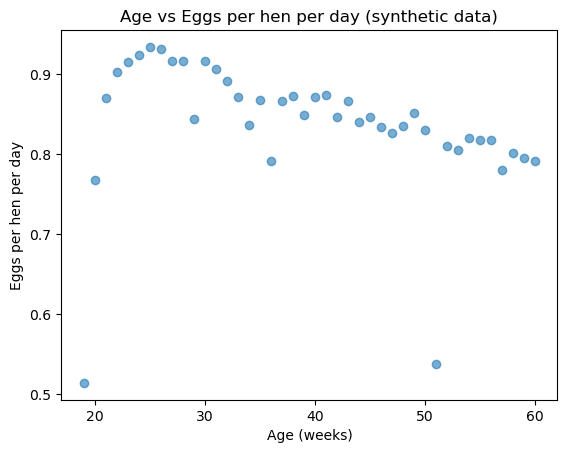

In [994]:

plt.scatter(X_train, Y_train, alpha=0.6)
plt.xlabel("Age (weeks)")
plt.ylabel("Eggs per hen per day")
plt.title("Age vs Eggs per hen per day (synthetic data)")
plt.show()

Learned parameters (linear regression):
w = -0.022407080144754867
b = 0.8377948145820199


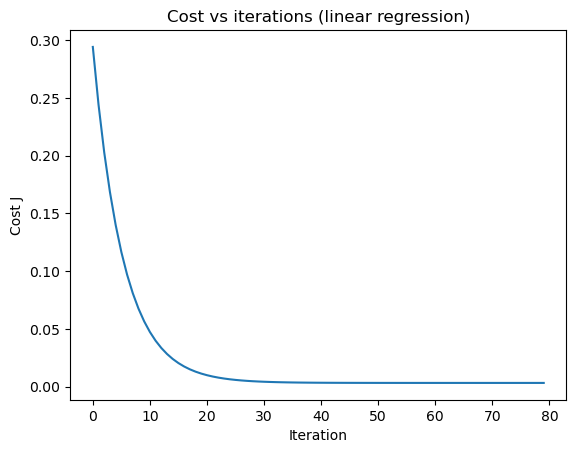

In [995]:
print("Learned parameters (linear regression):")
print("w =", w_j)
print("b =", b_j)

# Plot cost over iterations
plt.plot(j_history_out)
plt.xlabel("Iteration")
plt.ylabel("Cost J")
plt.title("Cost vs iterations (linear regression)")
plt.show()

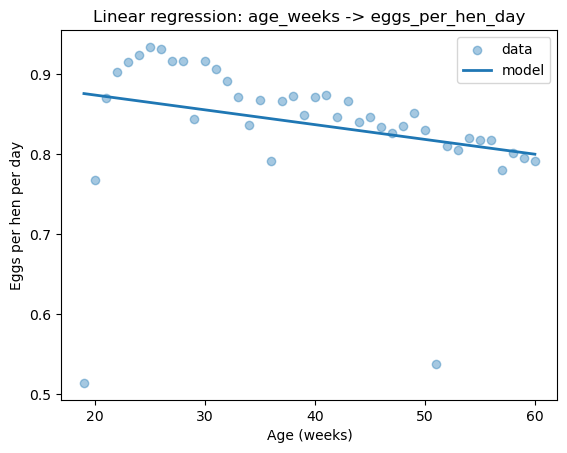

In [996]:
# Plot regression line vs data (convert normalized x back to original scale for plotting)
x_plot = np.linspace(X_train.min(), X_train.max(), 100).reshape(-1, 1)
x_plot_norm = (x_plot - X_mean) / X_std
y_plot = x_plot_norm * w_j + b_j
plt.scatter(X_train, Y_train, alpha=0.4, label="data")
plt.plot(x_plot, y_plot, label="model", linewidth=2)
plt.xlabel("Age (weeks)")
plt.ylabel("Eggs per hen per day")
plt.title("Linear regression: age_weeks -> eggs_per_hen_day")
plt.legend()
plt.show()